In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [2]:
df = pandas.read_csv("data/Sleep_health_and_lifestyle_dataset.csv")

In [3]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
df.shape

(374, 13)

In [5]:
df.info

<bound method DataFrame.info of      Person ID  Gender  Age            Occupation  Sleep Duration  \
0            1    Male   27     Software Engineer             6.1   
1            2    Male   28                Doctor             6.2   
2            3    Male   28                Doctor             6.2   
3            4    Male   28  Sales Representative             5.9   
4            5    Male   28  Sales Representative             5.9   
..         ...     ...  ...                   ...             ...   
369        370  Female   59                 Nurse             8.1   
370        371  Female   59                 Nurse             8.0   
371        372  Female   59                 Nurse             8.1   
372        373  Female   59                 Nurse             8.1   
373        374  Female   59                 Nurse             8.1   

     Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                   6                       42             6  

In [6]:
df.columns=df.columns.str.lower().str.replace(" ", "_")

In [7]:
df.columns

Index(['person_id', 'gender', 'age', 'occupation', 'sleep_duration',
       'quality_of_sleep', 'physical_activity_level', 'stress_level',
       'bmi_category', 'blood_pressure', 'heart_rate', 'daily_steps',
       'sleep_disorder'],
      dtype='object')

In [8]:
df.isnull().sum()

person_id                    0
gender                       0
age                          0
occupation                   0
sleep_duration               0
quality_of_sleep             0
physical_activity_level      0
stress_level                 0
bmi_category                 0
blood_pressure               0
heart_rate                   0
daily_steps                  0
sleep_disorder             219
dtype: int64

In [9]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [10]:
df.isnull().sum()

person_id                    0
gender                       0
age                          0
occupation                   0
sleep_duration               0
quality_of_sleep             0
physical_activity_level      0
stress_level                 0
bmi_category                 0
blood_pressure               0
heart_rate                   0
daily_steps                  0
sleep_disorder             219
dtype: int64

In [11]:
df.drop(columns=["sleep_disorder"], inplace=True)

In [13]:
df['decision_fatigue_index']=df['stress_level']*0.5 + (10-df['quality_of_sleep'])*0.3 - (df['physical_activity_level']/60)*0.2

In [14]:
df['cognitive_load']=df['stress_level']/df['sleep_duration']

DECISION FATIGUE INDEX COUNT 

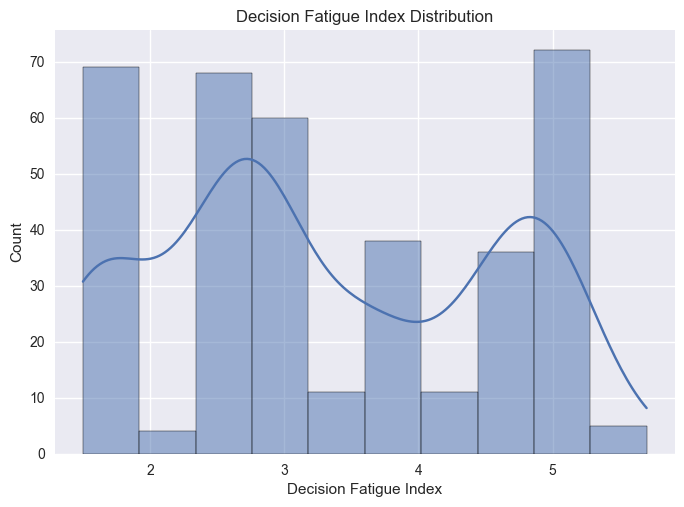

In [16]:
sns.histplot(df['decision_fatigue_index'],kde=True)
plt.title("Decision Fatigue Index Distribution")
plt.xlabel("Decision Fatigue Index")
plt.ylabel("Count")
plt.show()

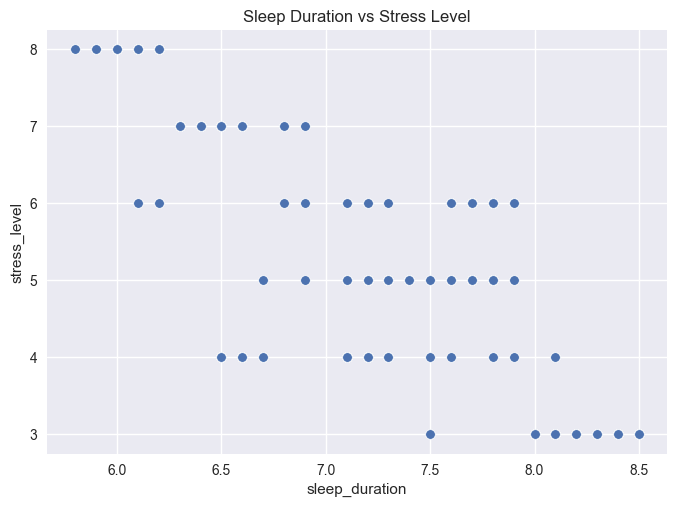

In [19]:
sns.scatterplot(x='sleep_duration', y='stress_level', data=df )
plt.title("Sleep Duration vs Stress Level")
plt.show()

DECISION FATIGUE INDEX VS STRESS LEVEL

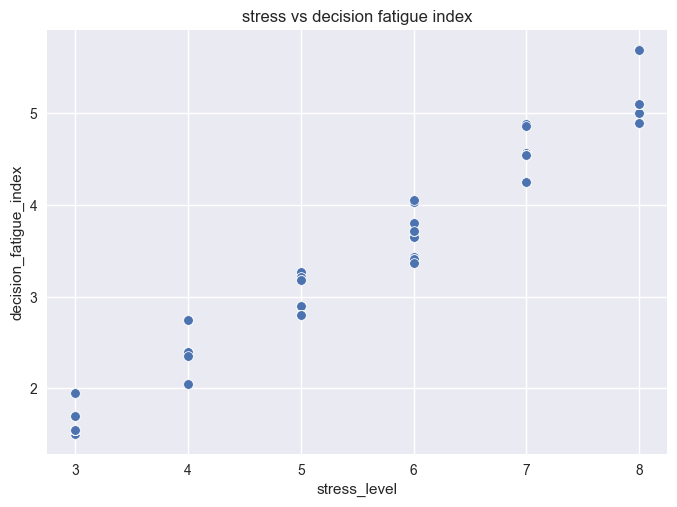

In [20]:
sns.scatterplot(x='stress_level', y='decision_fatigue_index', data=df)
plt.title("stress vs decision fatigue index")
plt.show()

DECISION FATIGUE VS SLEEP DURATION

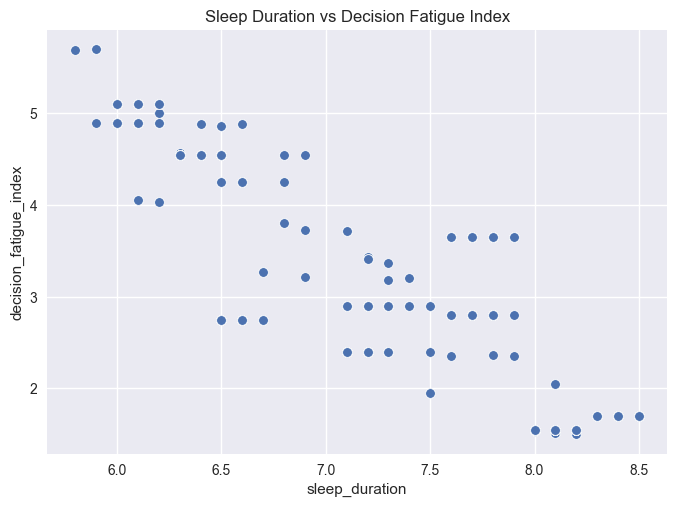

In [21]:
sns.scatterplot(x='sleep_duration',y='decision_fatigue_index', data=df)
plt.title("Sleep Duration vs Decision Fatigue Index")
plt.show()

CORRELATION HEATMAP

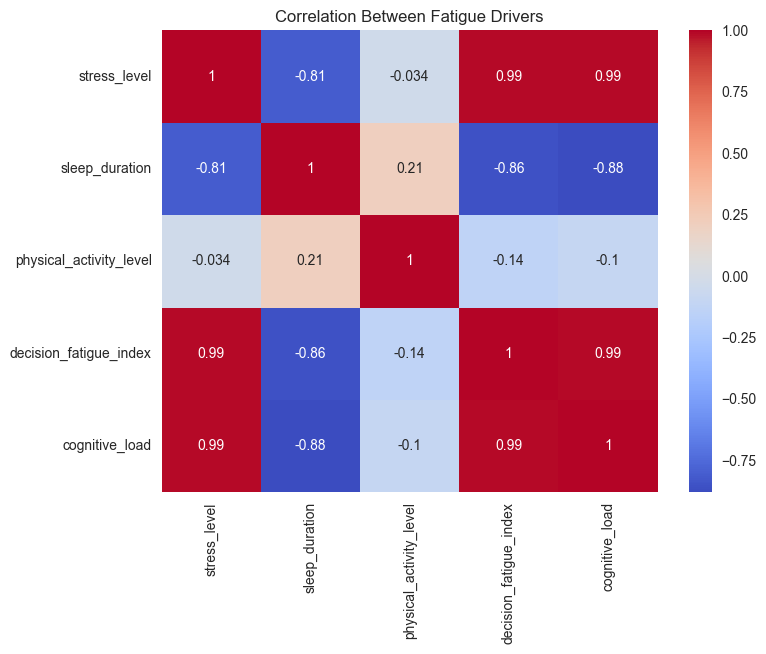

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['stress_level','sleep_duration',
        'physical_activity_level',
        'decision_fatigue_index',
        'cognitive_load']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Between Fatigue Drivers")
plt.show()


In [25]:
df['fatigue_risk'] = pd.cut(
    df['decision_fatigue_index'],
    bins=[-np.inf, 2.5, 4.5, np.inf],
    labels=['Low', 'Medium', 'High']
)


OCCUPATION ANALYSIS

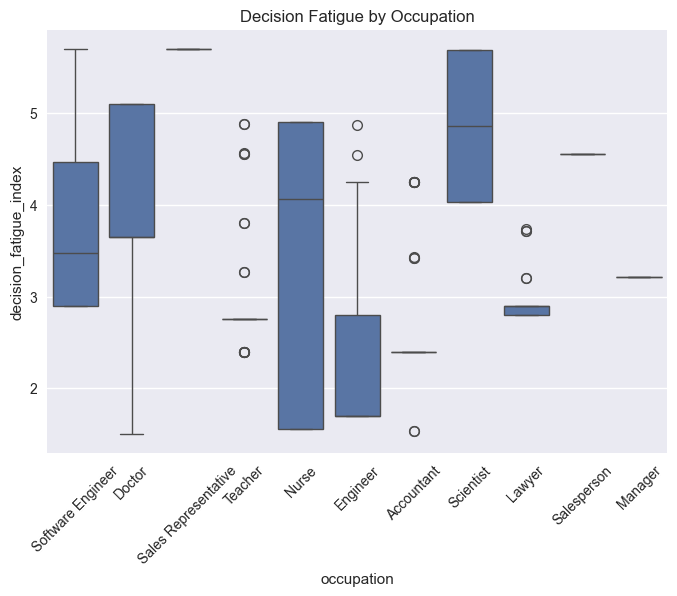

In [26]:
sns.boxplot(
    x='occupation',
    y='decision_fatigue_index',
    data=df
)
plt.xticks(rotation=45)
plt.title("Decision Fatigue by Occupation")
plt.show()


COGNITIVE LOAD VS DECISION FATIGUE INDEX

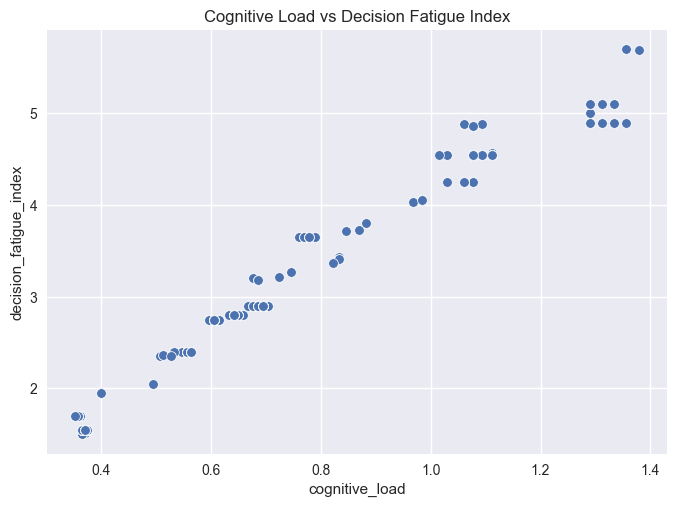

In [27]:
sns.scatterplot(
    x='cognitive_load',
    y='decision_fatigue_index',
    data=df
)
plt.title("Cognitive Load vs Decision Fatigue Index")
plt.show()
